<a href="https://colab.research.google.com/github/sha6durai-inosuke/BPE4943/blob/main/TNB_(5347_KL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#1. Install required packages
!pip install yfinance pandas ta scikit-learn shap matplotlib seaborn plotly

print("Packages installed!\n")


Packages installed!



In [24]:
#2. Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Libraries imported!\n")

Libraries imported!



In [25]:
#3. Download data

start, end = '2021-01-01', '2025-12-31'
tenaga = yf.download('5347.KL', start=start, end=end)
klci = yf.download('^KLSE', start=start, end=end)

data = tenaga.copy()

#Flatten multi-level columns if tehy exist
if isinstance(data.columns, pd.MultiIndex):
  data.columns = data.columns.droplevel(1)

data['KLCI_Close'] = klci['Close']
data.dropna(inplace=True)

print(f"Tenaga Nasional Berhad (5347.KL) data: {data.shape[0]} days")
print("Sample data:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume', 'KLCI_Close']].head())



/tmp/ipykernel_19535/2692817644.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tenaga = yf.download('5347.KL', start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_19535/2692817644.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  klci = yf.download('^KLSE', start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Tenaga Nasional Berhad (5347.KL) data: 1222 days
Sample data:
Price           Open      High       Low     Close   Volume   KLCI_Close
Date                                                                    
2021-01-04  8.064416  8.095079  8.018421  8.018421  4180700  1602.569946
2021-01-05  8.033751  8.110409  7.987757  8.079746  4030100  1608.349976
2021-01-06  8.079747  8.079747  7.895768  7.987757  6430700  1591.969971
2021-01-07  7.957094  8.110409  7.757783  8.064415  6756300  1602.949951
2021-01-08  8.033751  8.064415  7.849772  8.064415  7002400  1633.189941


In [26]:
#4. X: Technical Indicators + Market Benchmark

data['MA5'] = ta.trend.sma_indicator(data['Close'], window=5)
data['MA20'] = ta.trend.sma_indicator(data['Close'], window=20)
data['RSI'] = ta.momentum.rsi(data['Close'])
data['MACD'] = ta.trend.MACD(data['Close']).macd()
data['Volatility'] = data['Close'].rolling(20).std()
data['KLCI_Return'] = data['KLCI_Close'].pct_change()

print("Created 5 technical indicators + KLCI_Return:")
print(data[['MA5', 'MA20', 'RSI', 'MACD', 'Volatility', 'KLCI_Return']].tail())

Created 5 technical indicators + KLCI_Return:
Price             MA5       MA20        RSI      MACD  Volatility  KLCI_Return
Date                                                                          
2025-12-23  13.158693  12.789034  68.542252  0.086280    0.319159     0.003201
2025-12-24  13.229291  12.812566  65.716432  0.108692    0.341583     0.000996
2025-12-26  13.299889  12.831196  67.173871  0.129706    0.363059    -0.000721
2025-12-29  13.401864  12.865515  71.892228  0.161900    0.402525     0.002319
2025-12-30  13.448930  12.888067  67.166279  0.177456    0.425984     0.002106


In [27]:
#5. Y: Target Varible - Next-day Return

data['Next_Return'] = data['Close'].pct_change().shift(-1)
data.dropna(inplace=True)

print("Target: Next-day return")
print(data['Next_Return'].describe())

Target: Next-day return
count    1196.000000
mean        0.000556
std         0.011079
min        -0.057307
25%        -0.005002
50%         0.000000
75%         0.005361
max         0.058195
Name: Next_Return, dtype: float64


In [28]:
#6. Features and data cleaning

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'RSI', 'MACD', 'Volatility', 'KLCI_Return']

X = data[features].dropna()
y = data.loc[X.index, 'Next_Return'].dropna()
X = X.loc[y.index]

print(f"Clean dataset: {X.shape[0]} rows, {len(features)} features")
print("Features:", features)

Clean dataset: 1196 rows, 11 features
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'RSI', 'MACD', 'Volatility', 'KLCI_Return']


In [29]:
#7. 80/20 train-test

split = int(0.8 * len(X))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {X_train.shape} ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test: {X_test.shape} ({X_test.index[0].date()} to {X_test.index[-1].date()})")

Train: (956, 11) (2021-02-10 to 2025-01-03)
Test: (240, 11) (2025-01-06 to 2025-12-29)


In [30]:
#8. Tree-based model - Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10 )
rf_model.fit(X_train, y_train)

#performance metrics
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:4f}")


Random Forest Performance:
MAE: 0.0084
RMSE: 0.0117
R2: 0.024543


/tmp/ipykernel_19535/3196059513.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.tail(8), y='Feature', x='Importance', ax=axes[1,1], palette='viridis')


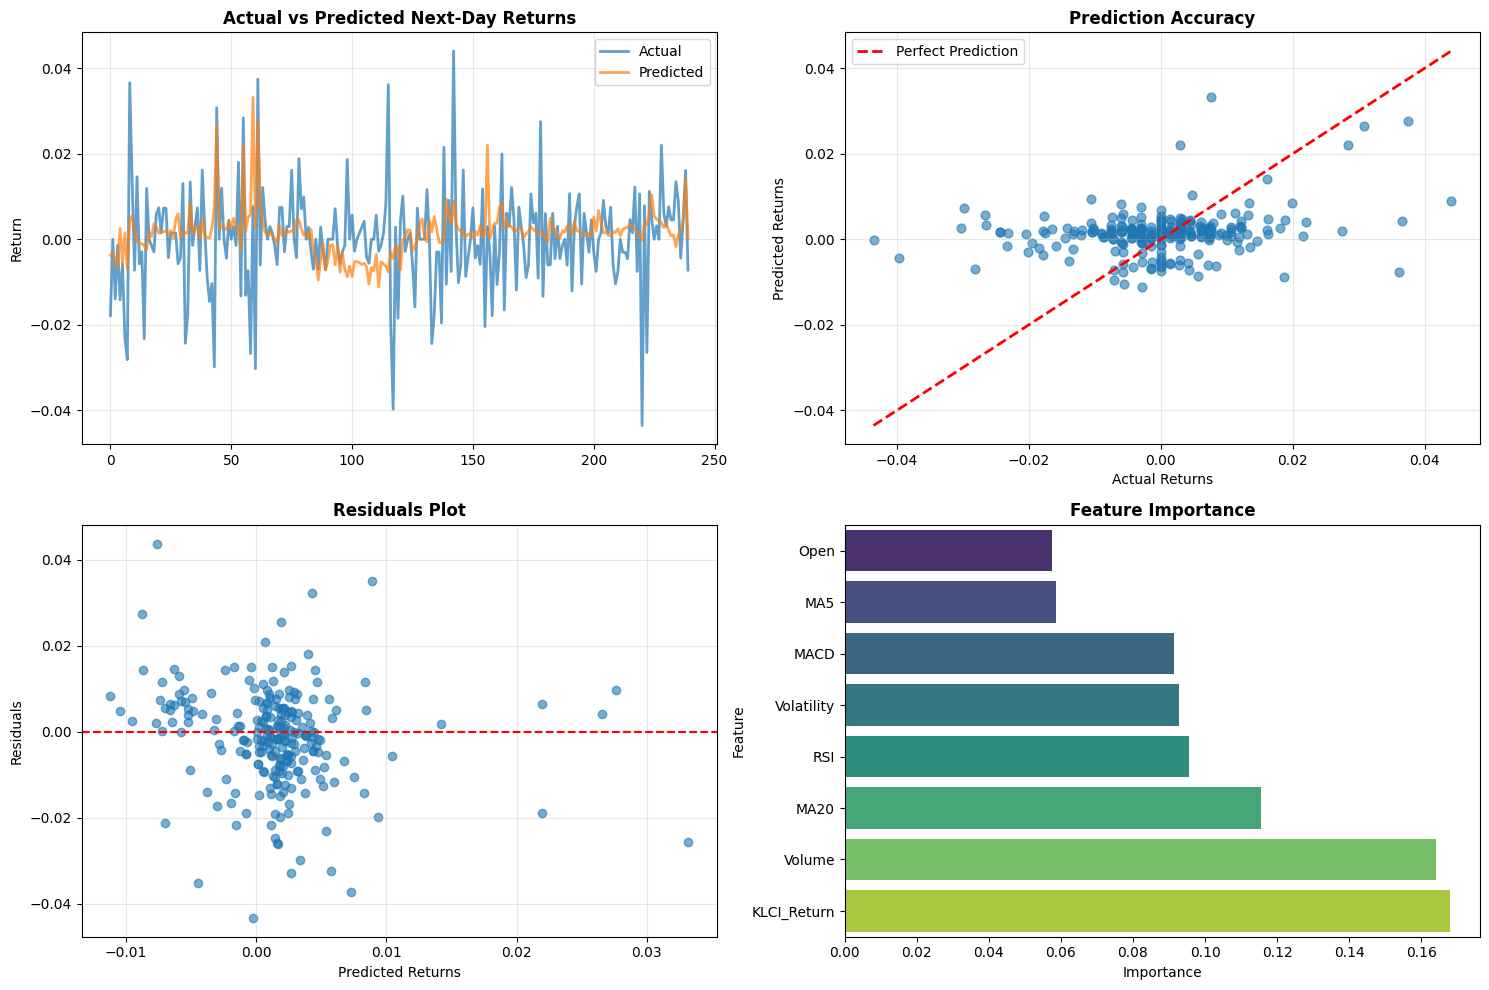

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Actual vs Predicted
axes[0,0].plot(y_test.values, label='Actual', alpha=0.7, linewidth=2)
axes[0,0].plot(y_pred, label='Predicted', alpha=0.7, linewidth=2)
axes[0,0].set_title('Actual vs Predicted Next-Day Returns', fontweight='bold')
axes[0,0].set_ylabel('Return')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Scatter plot
axes[0,1].scatter(y_test, y_pred, alpha=0.6, s=40)
perfect_line = [y_test.min(), y_test.max()]
axes[0,1].plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
axes[0,1].set_xlabel('Actual Returns')
axes[0,1].set_ylabel('Predicted Returns')
axes[0,1].set_title('Prediction Accuracy', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Residuals
residuals = y_test - y_pred
axes[1,0].scatter(y_pred, residuals, alpha=0.6)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Returns')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Residuals Plot', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Feature importance (built-in)
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=True)
sns.barplot(data=feat_df.tail(8), y='Feature', x='Importance', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Feature Importance', fontweight='bold')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


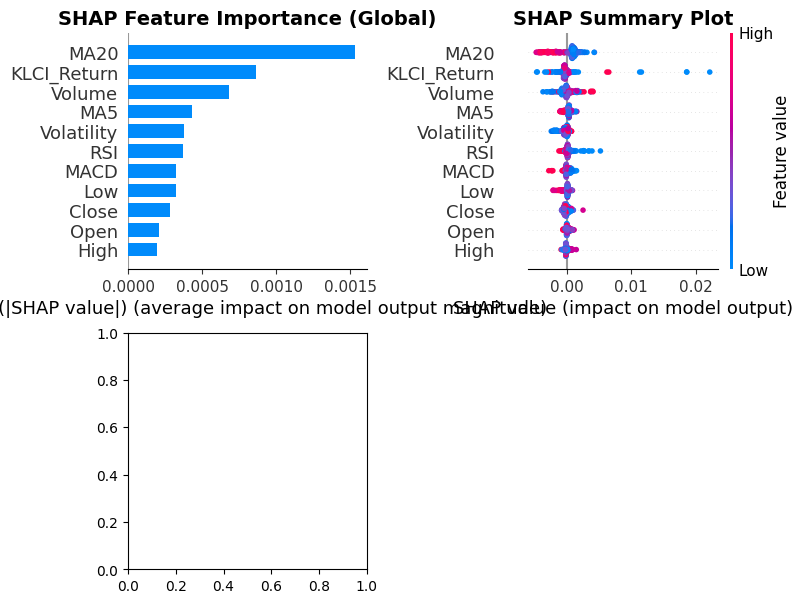

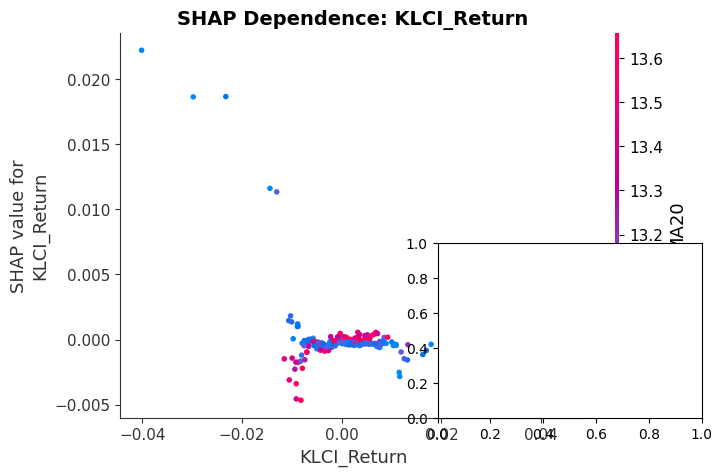

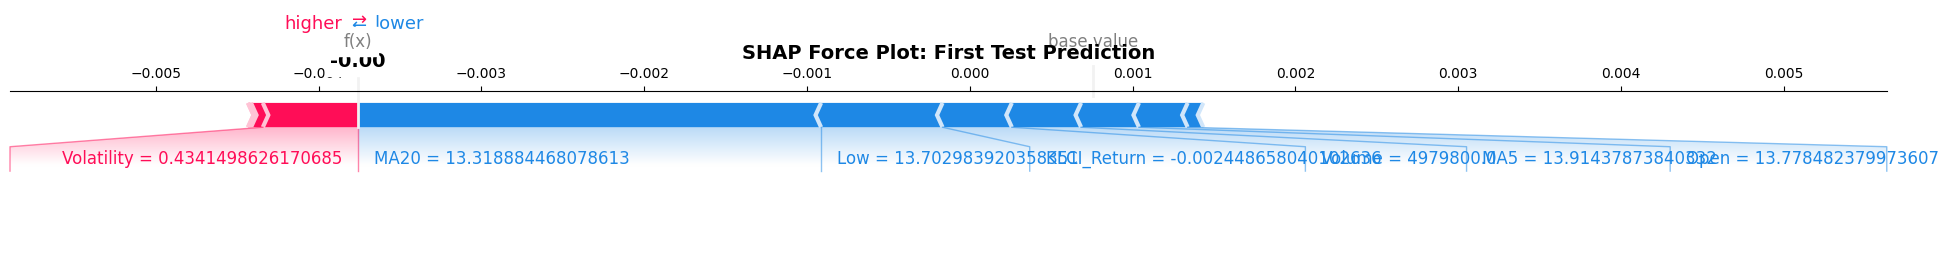

In [32]:
#10. XAI - SHAP Analysis

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(15, 12))

#SHAP Summary Plot
plt.subplot(2, 2, 1)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=11, show=False)
plt.title('SHAP Feature Importance (Global)', fontweight='bold', fontsize=14)

#SHAP Summary Scatter
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X_test, max_display=11, show=False)
plt.title('SHAP Summary Plot', fontweight='bold', fontsize=14)

#SHAP Dependence (Top Feauture)
top_feature = feat_df.iloc[-1]['Feature']
plt.subplot(2, 2, 3)
shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence: {top_feature}', fontweight='bold', fontsize=14)

#Single prediction force plot
plt.subplot(2, 2, 4)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True, show=False)
plt.title('SHAP Force Plot: First Test Prediction', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [35]:
#11. Export Delivarables
final_data = X.copy()
final_data['Next_Return'] = y
final_data['Predicted_Return'] = rf_model.predict(X)
final_data['Actual_Return'] = y
final_data.to_csv('tenaga_nasional_5347_complete.csv')

results_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})
results_summary.to_csv('performance_metrics.csv', index=False)

print("\nASSIGNMENT REQUIREMENTS FULFILLED:")
print("Company: Tenaga Nasional Berhad (5347.KL)")
print("Data period: 2021-01-01 to 2025-12-31")
print("5 technical indicators + KLCI_Return")
print("Target: Next-day return")
print("80/20 time-based split")
print("ONE tree-based model: Random Forest")
print("Regression metrics: MAE, RMSE, R2")
print("ONE XAI method: SHAP values")
print("\nFILES SAVED:")



ASSIGNMENT REQUIREMENTS FULFILLED:
Company: Tenaga Nasional Berhad (5347.KL)
Data period: 2021-01-01 to 2025-12-31
5 technical indicators + KLCI_Return
Target: Next-day return
80/20 time-based split
ONE tree-based model: Random Forest
Regression metrics: MAE, RMSE, R2
ONE XAI method: SHAP values

FILES SAVED:
